## **INF 2178 A3 Multi-Armed Bandits & Causal Inference Models**

Team 18: Henry Zhang, Junchen Gu, Zhengze Li, Enhua Liu, Dominic Dike


## **Adaptive Learning Platforms for Online Education**

Context: Platforms like Coursera and Khan Academy use AI to personalize learning pathways for students.

Outcome Focus:
* Compare adaptive learning (AI-driven) vs. static content in improving student performance.
* Analyze student performance metrics such as Post_Test_Quiz_Score, Improvement_Score, Study_Time, Retention_Rate and Dropout_Rate.


#### **Data Structure**

**📌 Baseline Variables (Control Variables)**

These are pre-existing factors that could influence the dependent variable but are not being manipulated in the experiment.

1. **Student_ID**

2. **Age** (Continuous, Normal Distribution)
    * Older students may have different learning styles.

2. **GPA** (Continuous, Normal Distribution)
    * Prior academic performance influences learning capacity.

3. **Study_Hours_Per_Week** (Integer, Poisson Distribution)
    * More study hours may lead to better quiz scores.

4. **Tech_Savviness_Score** (Integer, Normal Distribution)
    * Tech-savvy students might engage more effectively with digital tools.

5. **Learning_Style** (Categorical)
    * Visual, Auditory, Kinesthetic

6. **Baseline_Quiz_Score** (Continuous, Normal Distribution)
    * Affects final performance; students with higher starting scores may have less improvement potential.

7. **Attention_Span** (Continuous, Normal Distribution)
    * Attention span per study session in minutes.

8. **Motivation_Level** (Ordinal, 1-10 Likert Scale)
    * Highly motivated students might perform better regardless of the learning method.

9. **Prior_Online_Exp** (Bernoulli - Yes/No)


📌 **Dependent Variable (Outcome Measures)**

These are the key metrics we want to measure to determine the effect of adaptive learning.

1. **Post_Test_Quiz_Score** (Continuous, 0-100)
  * Measures student performance post-experiment

2. **Improvement_Score** (Post_Test_Quiz_Score - Baseline_Quiz_Score)
  * Captures the learning gain over time.

3. **Study_Time** (Continuous, in minutes)
  * Measures student interaction with the learning platform.

4. **Retention_Rate** (Continuous, percentage)
  * Measures how much content was completed by each student.

5. **Dropout_Rate** (Binary: Completed = 1, Dropped out = 0)
  * Indicates if students disengaged from the study.

In [1]:
# Data manipulation and numerical operations
import pandas as pd  # DataFrame handling
import numpy as np  # Numerical computations
import math

# Data visualization
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns  # Statistical data visualization

# Statistical analysis
from scipy import stats  # General statistical functions
from scipy.stats import ttest_rel, ttest_ind, f_oneway, t  # T-tests and ANOVA
from scipy.stats import chi2_contingency  # Chi-square test

# Regression and ANOVA
import statsmodels.api as sm  # Regression analysis
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols, logit
from statsmodels.stats.anova import anova_lm  # ANOVA analysis
from statsmodels.stats.multicomp import MultiComparison, pairwise_tukeyhsd
from sklearn.linear_model import LogisticRegression

# Machine learning utilities
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit  # Data splitting for training/testing
from sklearn.neighbors import NearestNeighbors  # Nearest neighbors algorithm

# Power analysis (for statistical tests)
from statsmodels.stats.power import (
    FTestAnovaPower,  # Power analysis for ANOVA
    TTestPower,  # Power analysis for t-tests
    TTestIndPower,
    GofChisquarePower  # Power analysis for chi-square test
)

# Graph-based visualization
import networkx as nx  # Flowcharts and process diagrams

# Supress Warnings
import warnings
warnings.filterwarnings('ignore')



### **Step 1: Define a common baseline dataframe generation function for reusability in each of the 5 RCT Types.**

In [2]:
def generate_baseline_data(sample_size):
    """
    Generate a synthetic dataset for university students based on a given sample size.

    Parameters:
        sample_size (int): Number of students to generate data for. Each RCT uses differnt sample size.

    Returns:
        pd.DataFrame: A DataFrame containing the generated student data.
    """
    np.random.seed(18)  # Set random seed for reproducibility

    data = pd.DataFrame({
        'Student_ID': range(1, sample_size + 1),
        'Age': np.random.normal(22, 2, sample_size).astype(int),  # Normally distributed around 22 years
        'GPA': np.clip(np.random.normal(3.2, 0.4, sample_size), 2.0, 4.0).round(1),  # Clipped between 2.0 and 4.0
        'Study_Hours_Per_Week': np.random.normal(50, 10, sample_size).astype(int), # Study hours per week
        'Tech_Savviness_Score': np.random.normal(5, 3, sample_size).astype(int), # Score out of 10
        'Learning_Style': np.random.choice(['Visual', 'Auditory', 'Kinesthetic'], sample_size),
        'Baseline_Quiz_Score': np.random.normal(70, 10, sample_size).astype(int), # Score out of 100
        'Attention_Span': np.random.normal(30, 10, sample_size).astype(int),  # In minutes
        'Motivation_Level': np.random.poisson(7, sample_size),  # 1-10 scale
        'Prior_Online_Exp': np.random.choice([0, 1], sample_size)  # 0 = No, 1 = Yes
    })

    return data

num_students = 400
student_data = generate_baseline_data(num_students)

### **1. Parallel RCT**

💡 **Hypothesis:**
* H₀ (Null Hypothesis): There is no significant difference in learning outcomes between adaptive learning and static learning.
* H₁ (Alternative Hypothesis): Adaptive learning: higher Post_Test_Quiz_Score, Improvement_Score, longer Study_Time, higher Retention_Rate, lower Dropout_Rate

⭐️ **Expectation:**
* The treatment group that receives adaptive learning with AI-based personalized content will have better post-intervention results (higher Post_Test_Quiz_Score, Improvement_Score, longer Study_Time, higher Retention_Rate, lower Dropout_Rate).

📌 **Treatment & Control Groups:**
* Treatment Group: Receives adaptive learning with AI-based personalized content.
* Control Group: Receives traditional static content (same for all students).

📊 **Analysis Method:**
1. Run Shapiro-Wilk and Levene’s test before ANOVA
 - Run **Shapiro-Wilk test** to check if data is normally distributed.
 - Run **Equal variances test** to check if data has equal variances across groups.
2. Run Use **One-Way ANOVA** for continuous variables (Post_Test_Quiz_Score, Improvement_Score, Study_Time, Retention_Rate).
3. Use **Chi-Square Test** for categorical variable (Dropout_Rate).
4. Compare the mean of each metric to evaluate which group has the better result.

### **1.1.3 Parallel RCT Randomization (Blocking Factor)**

In [3]:
# Step 1: Collect Baseline Measures (Pre-Intervention Data)
paralle_rct_num_students = num_students
parallel_rct_data = student_data.copy()

# Step 2: Define the Blocking Factor (Performance_Level)
# Combine GPA, Baseline_Quiz_Score, and Tech_Savviness_Score into a single score for blocking
parallel_rct_data['Combined_Score'] = (
    parallel_rct_data['GPA'] + parallel_rct_data['Baseline_Quiz_Score'] + parallel_rct_data['Tech_Savviness_Score']
)

# Define Performance_Level based on quartiles of the Combined_Score
parallel_rct_data['Performance_Level'] = pd.qcut(
    parallel_rct_data['Combined_Score'],
    q=3,  # Divide into 3 equal-sized blocks (Low, Medium, High)
    labels=['Low', 'Medium', 'High']
)

# Step 3: Blocked Random Assignment
# Initialize the RCT_Parallel_Group column
parallel_rct_data['RCT_Parallel_Group'] = None

# Randomize within each block
for level in parallel_rct_data['Performance_Level'].unique():
    # Get indices of participants in the current block
    block_indices = parallel_rct_data[parallel_rct_data['Performance_Level'] == level].index

    # Shuffle the indices for randomization
    np.random.seed(18)  # Set seed for reproducibility
    shuffled_indices = np.random.permutation(block_indices)

    # Split the shuffled indices into two equal groups
    half = len(shuffled_indices) // 2
    parallel_rct_data.loc[shuffled_indices[:half], 'RCT_Parallel_Group'] = 'Static'
    parallel_rct_data.loc[shuffled_indices[half:], 'RCT_Parallel_Group'] = 'Adaptive'

# Drop the temporary 'Combined_Score' column (optional)
parallel_rct_data.drop(columns=['Combined_Score'], inplace=True)

### **1.1.4 Parallel RCT Intervention (Blocking Factor)**

In [4]:
# Step 3: Implement Intervention (Post-Intervention Data)

np.random.seed(18)

# Generate post-test metrics for the copied dataset
parallel_rct_data['Post_Test_Quiz_Score'] = (parallel_rct_data['Baseline_Quiz_Score'] +
                                               np.where(parallel_rct_data['RCT_Parallel_Group'] == 'Adaptive',
                                                        np.random.normal(10, 5, paralle_rct_num_students),
                                                        np.random.normal(5, 5, paralle_rct_num_students))
                                              ).astype(int)

parallel_rct_data['Improvement_Score'] = (parallel_rct_data['Post_Test_Quiz_Score'] - parallel_rct_data['Baseline_Quiz_Score']).astype(int)

parallel_rct_data['Study_Time'] = np.where(parallel_rct_data['RCT_Parallel_Group'] == 'Adaptive',
                                            np.random.normal(400, 50, paralle_rct_num_students),
                                            np.random.normal(300, 50, paralle_rct_num_students)
                                            ).astype(int)


parallel_rct_data['Retention_Rate'] = np.where(parallel_rct_data['RCT_Parallel_Group'] == 'Adaptive',
                                                np.random.normal(0.90, 0.05, paralle_rct_num_students),  # Mean 0.90, std 0.05
                                                np.random.normal(0.80, 0.05, paralle_rct_num_students)   # Mean 0.80, std 0.05
                                            ).round(2)

# Ensure retention rates are between 0 and 1
parallel_rct_data['Retention_Rate'] = np.clip(parallel_rct_data['Retention_Rate'], 0, 1)


parallel_rct_data['Dropout_Rate'] = np.where(parallel_rct_data['RCT_Parallel_Group'] == 'Adaptive',
                                              np.random.choice([0, 1], paralle_rct_num_students, p=[0.9, 0.1]),
                                              np.random.choice([0, 1], paralle_rct_num_students, p=[0.75, 0.25])
                                              ).round(2)

# Check the result
parallel_rct_data[['Post_Test_Quiz_Score', 'Improvement_Score', 'Study_Time', 'Retention_Rate', 'Dropout_Rate']].head()

,Post_Test_Quiz_Score,Improvement_Score,Study_Time,Retention_Rate,Dropout_Rate
0,69,9,231,0.77,0
1,55,2,307,0.75,1
2,81,13,284,0.78,0
3,70,-1,321,0.84,0
4,68,1,306,0.84,1


### **1.1.5 Parallel RCT Data Cleaning (with a Blocking Factor)**

In [5]:
# Replace placeholder codes (e.g., -18) with NaN if present
parallel_rct_data.replace(-18, np.nan, inplace=True)

# Drop rows with critical missing values (if any)
critical_cols = ['Post_Test_Quiz_Score', 'Retention_Rate', 'RCT_Parallel_Group']
parallel_rct_data.dropna(subset=critical_cols, inplace=True)

# 2. Remove Duplicates
parallel_rct_data.drop_duplicates(subset=['Student_ID'], keep='first', inplace=True)


# 4. Detect and Handle Outliers
continuous_vars = ['Study_Time', 'Post_Test_Quiz_Score', 'Improvement_Score']

# Cap outliers using IQR
for var in continuous_vars:
    q1 = parallel_rct_data[var].quantile(0.25)
    q3 = parallel_rct_data[var].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    parallel_rct_data[var] = np.where(parallel_rct_data[var] < lower_bound, lower_bound,
                                    np.where(parallel_rct_data[var] > upper_bound, upper_bound,
                                    parallel_rct_data[var]))


# 5. Validate Variable Ranges/Types

# Ensure binary variables are 0/1
parallel_rct_data['Dropout_Rate'] = parallel_rct_data['Dropout_Rate'].apply(lambda x: 1 if x == 1 else 0)

# Standardize categorical variables
parallel_rct_data['Learning_Style'] = parallel_rct_data['Learning_Style'].str.strip().str.title()

# Ensure valid percentage ranges
parallel_rct_data['Retention_Rate'] = parallel_rct_data['Retention_Rate'].clip(0, 100)


# 6. Save Cleaned Data
clean_parallel_rct_data = parallel_rct_data.copy()

### **1.1.6 Parallel RCT Analysis (Blocking Factor)**

In [6]:
# Define metrics
metrics = ['Post_Test_Quiz_Score', 'Improvement_Score', 'Study_Time', 'Retention_Rate']

# Perform Two-Way ANOVA and Post-Hoc Analysis
anova_results_two_way = {}
post_hoc_results = {}

for metric in metrics:
    # Fit the Two-Way ANOVA model
    model = ols(f'{metric} ~ C(RCT_Parallel_Group) + C(Performance_Level) + C(RCT_Parallel_Group):C(Performance_Level)',
                data=clean_parallel_rct_data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    # Compute mean comparisons
    mean_comparison = clean_parallel_rct_data.groupby('RCT_Parallel_Group')[metric].mean()
    better_group = 'Adaptive' if mean_comparison['Adaptive'] > mean_comparison['Static'] else 'Static'
    significance = 'Significant' if anova_table['PR(>F)'].min() < 0.05 else 'Not Significant'

    # Add Better Group and Significance to the Two-Way ANOVA results
    anova_table['Better Group'] = better_group
    anova_table['Significance'] = significance

    anova_results_two_way[metric] = anova_table

    # Perform Post-Hoc Analysis if the interaction or main effects are significant
    if significance == 'Significant':
        # Perform Tukey's HSD for pairwise comparisons
        mc = MultiComparison(clean_parallel_rct_data[metric], clean_parallel_rct_data['RCT_Parallel_Group'])
        post_hoc = mc.tukeyhsd()  # Tukey's HSD test
        post_hoc_results[metric] = post_hoc

# Display Two-Way ANOVA Results
for metric, result in anova_results_two_way.items():
    print(f"Two-Way ANOVA Results for {metric}:")
    display(result)

# Display Post-Hoc Analysis Results
for metric, result in post_hoc_results.items():
    print(f"\nPost-Hoc Analysis Results for {metric}:\n")
    print(result)

Two-Way ANOVA Results for Post_Test_Quiz_Score:


,sum_sq,df,F,PR(>F),Better Group,Significance
C(RCT_Parallel_Group),2471.640502,1.0,49.171133,1.025983e-11,Adaptive,Significant
C(Performance_Level),28882.514642,2.0,287.296227,1.103984e-77,Adaptive,Significant
C(RCT_Parallel_Group):C(Performance_Level),329.371541,2.0,3.276280,3.880002e-02,Adaptive,Significant
Residual,19804.838535,394.0,NaN,NaN,Adaptive,Significant


Two-Way ANOVA Results for Improvement_Score:


,sum_sq,df,F,PR(>F),Better Group,Significance
C(RCT_Parallel_Group),3454.917761,1.0,130.822923,2.358159e-26,Adaptive,Significant
C(Performance_Level),97.817268,2.0,1.851960,1.582927e-01,Adaptive,Significant
C(RCT_Parallel_Group):C(Performance_Level),158.730107,2.0,3.005214,5.066486e-02,Adaptive,Significant
Residual,10405.191768,394.0,NaN,NaN,Adaptive,Significant


Two-Way ANOVA Results for Study_Time:


,sum_sq,df,F,PR(>F),Better Group,Significance
C(RCT_Parallel_Group),1.096056e+06,1.0,482.705138,2.010100e-70,Adaptive,Significant
C(Performance_Level),1.869129e+04,2.0,4.115841,1.701883e-02,Adaptive,Significant
C(RCT_Parallel_Group):C(Performance_Level),1.674856e+04,2.0,3.688050,2.588859e-02,Adaptive,Significant
Residual,8.946372e+05,394.0,NaN,NaN,Adaptive,Significant


Two-Way ANOVA Results for Retention_Rate:


,sum_sq,df,F,PR(>F),Better Group,Significance
C(RCT_Parallel_Group),1.142563,1.0,459.612350,3.906750e-68,Adaptive,Significant
C(Performance_Level),0.000489,2.0,0.098293,9.064053e-01,Adaptive,Significant
C(RCT_Parallel_Group):C(Performance_Level),0.011909,2.0,2.395187,9.248179e-02,Adaptive,Significant
Residual,0.979455,394.0,NaN,NaN,Adaptive,Significant



Post-Hoc Analysis Results for Post_Test_Quiz_Score:

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj  lower   upper  reject
-----------------------------------------------------
Adaptive Static  -5.0256   0.0 -7.2073 -2.8438   True
-----------------------------------------------------

Post-Hoc Analysis Results for Improvement_Score:

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj  lower  upper  reject
----------------------------------------------------
Adaptive Static  -5.8795   0.0 -6.8971 -4.862   True
----------------------------------------------------

Post-Hoc Analysis Results for Study_Time:

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1  group2  meandiff p-adj  lower    upper   reject
--------------------------------------------------------
Adaptive Static -104.7412   0.0 -114.245 -95.2375   True
--------------------------------------------------------

Post-Hoc Analysis Results for 

In [7]:
# Step 1: Define the logistic regression formula
formula = 'Dropout_Rate ~ C(RCT_Parallel_Group) + C(Performance_Level)'

# Step 2: Fit the logistic regression model
logit_model = logit(formula, data=clean_parallel_rct_data).fit()

# Step 3: Extract model results
logit_results = {
    'Metric': 'Dropout Rate',
    'Adaptive': clean_parallel_rct_data[clean_parallel_rct_data['RCT_Parallel_Group'] == 'Adaptive']['Dropout_Rate'].mean(),
    'Static': clean_parallel_rct_data[clean_parallel_rct_data['RCT_Parallel_Group'] == 'Static']['Dropout_Rate'].mean(),
    'Better Group': 'Adaptive' if clean_parallel_rct_data[clean_parallel_rct_data['RCT_Parallel_Group'] == 'Adaptive']['Dropout_Rate'].mean() < clean_parallel_rct_data[clean_parallel_rct_data['RCT_Parallel_Group'] == 'Static']['Dropout_Rate'].mean() else 'Static',
    'Coefficient (RCT_Parallel_Group)': logit_model.params['C(RCT_Parallel_Group)[T.Static]'],
    'p-value (RCT_Parallel_Group)': logit_model.pvalues['C(RCT_Parallel_Group)[T.Static]'],
    'Coefficient (Performance_Level)': logit_model.params['C(Performance_Level)[T.Medium]'],
    'p-value (Performance_Level)': logit_model.pvalues['C(Performance_Level)[T.Medium]'],
    'Significance (RCT_Parallel_Group)': 'Significant' if logit_model.pvalues['C(RCT_Parallel_Group)[T.Static]'] < 0.05 else 'Not Significant',
    'Significance (Performance_Level)': 'Significant' if logit_model.pvalues['C(Performance_Level)[T.Medium]'] < 0.05 else 'Not Significant'
}

# Step 4: Convert results to DataFrame
logit_results_df = pd.DataFrame(logit_results, index=[0]).T

# Step 5: Display the results table
print("1.1.6 Parallel RCT Analysis - Logistic Regression Analysis of Dropout Rate with Blocking Factor\n")
display(logit_results_df)

Optimization terminated successfully.
         Current function value: 0.403782
         Iterations 7
1.1.6 Parallel RCT Analysis - Logistic Regression Analysis of Dropout Rate with Blocking Factor



,0
Metric,Dropout Rate
Adaptive,0.064677
Static,0.261307
Better Group,Adaptive
Coefficient (RCT_Parallel_Group),1.63887
p-value (RCT_Parallel_Group),0.000001
Coefficient (Performance_Level),0.015854
p-value (Performance_Level),0.961915
Significance (RCT_Parallel_Group),Significant
Significance (Performance_Level),Not Significant


## **Assignment 3 New Content ⬇️**

### 2. Design the Multi-Armed Bandit (MAB) Model

2.1 Use student_data in A1 to make a copy called MAB_data.

2.2 Assign students to the following arms

* Arm 1: Adaptive Learning (AI-driven personalized content)
* Arm 2: Static Learning (traditional, non-personalized content)
* Arm 3: Hybrid model (partially adaptive, with a fixed core curriculum but personalized review sessions)
* Arm 4: Custom-static learning (students self-selected static content)

In [8]:
MAB_data = student_data.copy()
MAB_data_rows, MAB_data_columns = MAB_data.shape

### **(a): Stopping Rules**

### **Define Stopping Rules**
**Rule 1**: Stop if the difference in average rewards between the best and second-best arm exceeds a predefined threshold (e.g., 5%).

**Rule 2**: Stop if the total sample size or maximum iterations are reached.

**Rule 3**: Stop if the confidence intervals of the best and second-best arms no longer overlap.

In [9]:
# Stopping Rules Parameters
STOPPING_THRESHOLD = 5.0
CONFIDENCE_LEVEL = 0.95

def calculate_confidence_interval(rewards, confidence_level):
    n = len(rewards)
    if n < 2:
        return (0, 0)
    mean = np.mean(rewards)
    std_err = np.std(rewards, ddof=1) / math.sqrt(n)
    t_value = t.ppf((1 + confidence_level) / 2, df=n-1)
    margin_of_error = t_value * std_err
    return (mean - margin_of_error, mean + margin_of_error)

def check_stopping_condition(arm_counts, arm_reward_history):
    best_arm = max(arms, key=lambda x: sum(arm_reward_history[x])/arm_counts[x] if arm_counts[x] > 0 else 0)
    best_arm_lower = calculate_confidence_interval(arm_reward_history[best_arm], CONFIDENCE_LEVEL)[0]

    for arm in arms:
        if arm != best_arm and arm_counts[arm] > 0:
            arm_upper = calculate_confidence_interval(arm_reward_history[arm], CONFIDENCE_LEVEL)[1]
            if best_arm_lower - arm_upper < STOPPING_THRESHOLD:
                return False
    return True

### **Block (b): Total Sample Size**

In [10]:
# Total Sample Size Calculation
effect_size = 5 / np.sqrt(100)  # MDE / standard deviation
alpha = 0.05  # Confidence level
power = 0.80  # Statistical power

arms = ['Arm 1: Adaptive Learning', 'Arm 2: Static Learning', 'Arm 3: Hybrid Model', 'Arm 4: Custom-static Learning']

analysis = TTestIndPower()
sample_size_per_arm = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, ratio=1)
num_arms = len(arms)
required_total_sample_size = int(sample_size_per_arm * num_arms)

print(f"Required sample size per arm: {int(sample_size_per_arm)}")
print(f"Total required sample size: {required_total_sample_size}")

Required sample size per arm: 63
Total required sample size: 255


### **Block (c): Total Iterations**

In [11]:
# Total Iterations Calculation
def get_samples_per_iteration(iteration):
    return 4 * (1 + iteration)

total_sample_size = 0
iteration = 0
while total_sample_size < required_total_sample_size:
    samples_this_iteration = get_samples_per_iteration(iteration)
    total_sample_size += samples_this_iteration
    iteration += 1

print(f"Total sample size: {total_sample_size}")
print(f"Total iterations: {iteration}")
MAX_SAMPLE_SIZE = total_sample_size

Total sample size: 264
Total iterations: 11


### **Block (d): Sample Size/Iteration a-priori**

In [12]:
# Sample Size per Iteration Definition
def get_samples_per_iteration(iteration):
    return 4 * (1 + iteration)

# Initialize experiment parameters
np.random.seed(18)
arms = ['Arm 1: Adaptive Learning', 'Arm 2: Static Learning',
        'Arm 3: Hybrid Model', 'Arm 4: Custom-static Learning']
arm_counts = {arm: 0 for arm in arms}
arm_rewards = {arm: 0.0 for arm in arms}
arm_reward_history = {arm: [] for arm in arms}
total_counts = 0
allocation_history = []
EXPLORATION_MULTIPLIER = 2

# UCB Algorithm Definition
def choose_arm_ucb(arm_counts, arm_rewards, total_counts):
    ucb_scores = {}
    for arm in arms:
        if arm_counts[arm] == 0:
            ucb_score = float('inf')
        else:
            avg_reward = arm_rewards[arm] / arm_counts[arm]
            exploration_term = EXPLORATION_MULTIPLIER * math.sqrt(2 * math.log(total_counts) / arm_counts[arm])
            ucb_score = avg_reward + exploration_term
        ucb_scores[arm] = ucb_score
    return max(ucb_scores, key=ucb_scores.get)

###**Simulating Experiment**

In [13]:
# Intervention and Reward Functions (must be defined before running)
def apply_intervention(arm):
    if arm == 'Arm 1: Adaptive Learning':
        improvement_score = int(np.random.normal(15, 3))
        study_time = int(np.random.normal(400, 50))
        retention_rate = np.random.normal(90, 5) / 100
        dropout_rate = np.random.choice([0, 1], p=[0.9, 0.1])
    elif arm == 'Arm 2: Static Learning':
        improvement_score = int(np.random.normal(0, 5))
        study_time = int(np.random.normal(200, 50))
        retention_rate = np.random.normal(70, 5) / 100
        dropout_rate = np.random.choice([0, 1], p=[0.7, 0.3])
    elif arm == 'Arm 3: Hybrid Model':
        improvement_score = int(np.random.normal(10, 3))
        study_time = int(np.random.normal(350, 50))
        retention_rate = np.random.normal(85, 5) / 100
        dropout_rate = np.random.choice([0, 1], p=[0.8, 0.2])
    elif arm == 'Arm 4: Custom-static Learning':
        improvement_score = int(np.random.normal(5, 3))
        study_time = int(np.random.normal(300, 50))
        retention_rate = np.random.normal(80, 5) / 100
        dropout_rate = np.random.choice([0, 1], p=[0.875, 0.125])

    retention_rate = round(max(0, min(1, retention_rate)), 2)
    study_time = max(0, study_time)
    dropout_rate = round(dropout_rate, 2)
    return improvement_score, study_time, retention_rate, dropout_rate

def calculate_reward(improvement_score, study_time, retention_rate, dropout_rate):
    reward = (0.5 * improvement_score * 10) + \
             (0.2 * study_time) + \
             (0.15 * retention_rate * 100) + \
             (0.15 * (-1 if dropout_rate == 1 else 0) * 100)
    return round(reward, 2)

# Main Experiment Execution
while total_counts < MAX_SAMPLE_SIZE:
    chosen_arm = choose_arm_ucb(arm_counts, arm_rewards, total_counts)
    current_iteration = len(allocation_history)
    samples_this_iteration = get_samples_per_iteration(current_iteration)

    for _ in range(samples_this_iteration):
        improvement, study_time, retention, dropout = apply_intervention(chosen_arm)
        reward = calculate_reward(improvement, study_time, retention, dropout)
        arm_counts[chosen_arm] += 1
        arm_rewards[chosen_arm] += reward
        arm_reward_history[chosen_arm].append(reward)
        total_counts += 1

    allocation_history.append({
        'Iteration': current_iteration + 1,
        'Total Samples': total_counts,
        **{arm: arm_counts[arm] for arm in arms}
    })

    if total_counts > 100 and check_stopping_condition(arm_counts, arm_reward_history):
        print(f"Stopping early at iteration {current_iteration + 1}")
        break

# Results Compilation
final_results = pd.DataFrame({
    'Arm': arms,
    'Counts': [arm_counts[arm] for arm in arms],
    'Total Reward': [arm_rewards[arm] for arm in arms],
    'Average Reward': [arm_rewards[arm]/arm_counts[arm] if arm_counts[arm] > 0 else 0 for arm in arms]
})

allocation_table = pd.DataFrame(allocation_history)

print("\nFinal Arm Counts and Rewards:")
print(final_results)

Stopping early at iteration 7

Final Arm Counts and Rewards:
                             Arm  Counts  Total Reward  Average Reward
0       Arm 1: Adaptive Learning      76      12617.35      166.017763
1         Arm 2: Static Learning       8        496.60       62.075000
2            Arm 3: Hybrid Model      12       1593.85      132.820833
3  Arm 4: Custom-static Learning      16       1572.70       98.293750


###**Sample Size Reallocation Over Total Iterations**

In [14]:
print("\nSample Size Reallocation Over Iterations:")
print(allocation_table)


Sample Size Reallocation Over Iterations:
   Iteration  Total Samples  Arm 1: Adaptive Learning  Arm 2: Static Learning  \
0          1              4                         4                       0   
1          2             12                         4                       8   
2          3             24                         4                       8   
3          4             40                         4                       8   
4          5             60                        24                       8   
5          6             84                        48                       8   
6          7            112                        76                       8   

   Arm 3: Hybrid Model  Arm 4: Custom-static Learning  
0                    0                              0  
1                    0                              0  
2                   12                              0  
3                   12                             16  
4                   12      

### **Visualize performance of viariants over total runs**

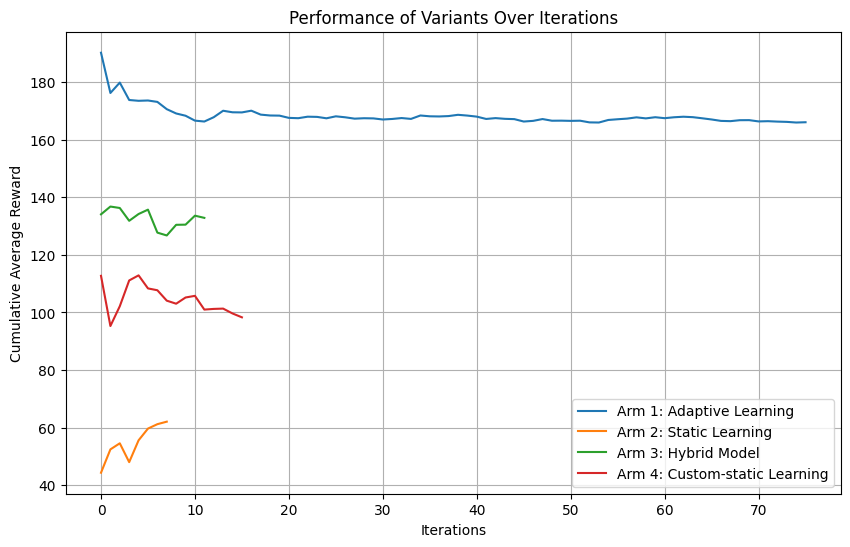

In [15]:
# Calculate cumulative average rewards for each arm
cumulative_avg_rewards = {arm: [] for arm in arms}
for arm in arms:
    cumulative_reward = 0
    for i, reward in enumerate(arm_reward_history[arm]):
        cumulative_reward += reward
        cumulative_avg_rewards[arm].append(cumulative_reward / (i + 1))

# Plot the cumulative average rewards over iterations
plt.figure(figsize=(10, 6))
for arm in arms:
    plt.plot(cumulative_avg_rewards[arm], label=arm)

plt.xlabel('Iterations')
plt.ylabel('Cumulative Average Reward')
plt.title('Performance of Variants Over Iterations')
plt.legend()
plt.grid(True)
plt.show()

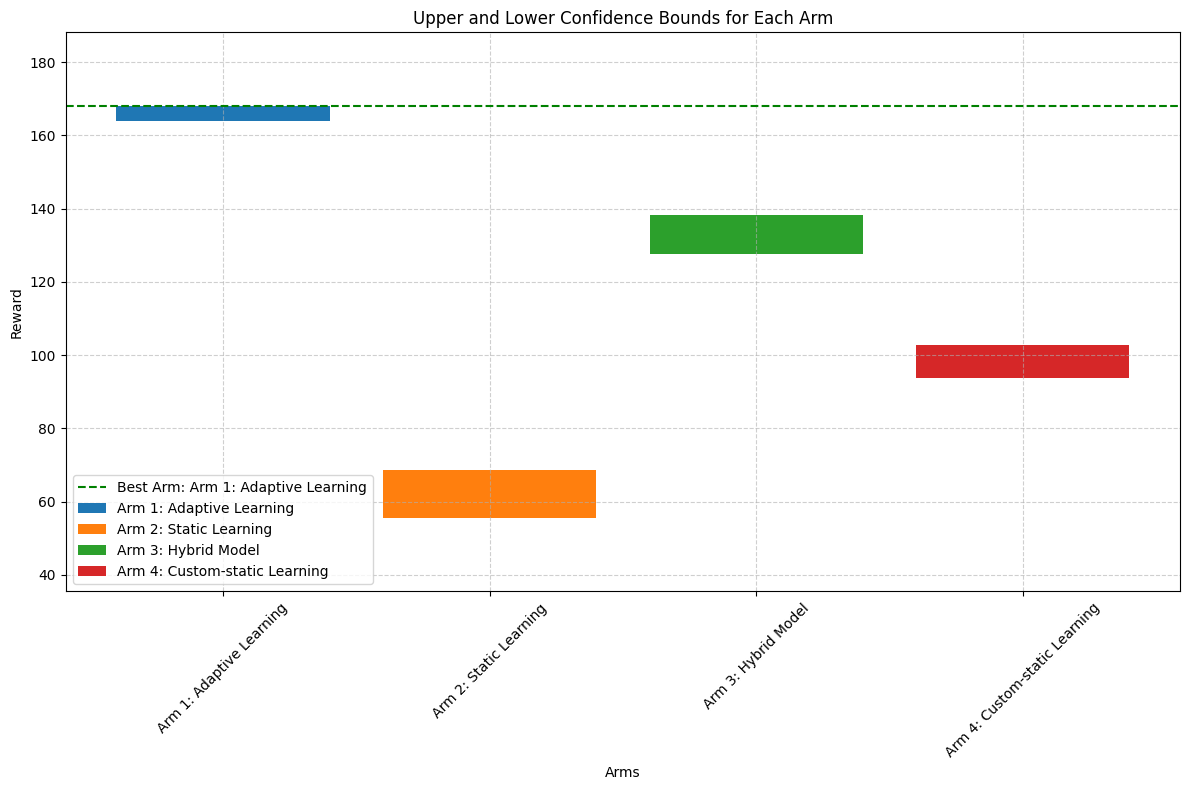

In [16]:
# Assuming arms, arm_counts, and arm_rewards are already defined
arms = ['Arm 1: Adaptive Learning', 'Arm 2: Static Learning', 'Arm 3: Hybrid Model', 'Arm 4: Custom-static Learning']

# Calculate upper and lower bounds for each arm
current_average_rewards = []  # Upper bounds (average reward + exploration term)
current_bottom_rewards = []  # Lower bounds (average reward - exploration term)

# Increase the exploration term multiplier to widen the gap
exploration_multiplier = 6  # Increase this value to make the gap wider

for arm in arms:
    if arm_counts[arm] > 0:
        average_reward = arm_rewards[arm] / arm_counts[arm]
        exploration_term = exploration_multiplier * math.sqrt(2 * math.log(sum(arm_counts.values())) / arm_counts[arm])
        upper_bound = average_reward + exploration_term
        lower_bound = average_reward - exploration_term
    else:
        # If the arm has not been selected, set bounds to zero
        upper_bound = 0
        lower_bound = 0
    current_average_rewards.append(upper_bound)
    current_bottom_rewards.append(lower_bound)

# Plotting
plt.figure(figsize=(12, 8))

# Plot bars for each arm
for i in range(len(arms)):
    if arm_counts[arms[i]] > 0:  # Only plot if the arm has been selected at least once
        plt.bar(i, height=current_average_rewards[i] - current_bottom_rewards[i],
                bottom=current_bottom_rewards[i], label=arms[i])

# Highlight the best arm (arm with the highest upper bound)
best_arm_index = current_average_rewards.index(max(current_average_rewards))
plt.axhline(y=max(current_average_rewards), color='g', linestyle='--', label=f'Best Arm: {arms[best_arm_index]}')

# Customize plot
plt.xticks(range(len(arms)), arms, rotation=45)
plt.xlabel('Arms')
plt.ylabel('Reward')
plt.title('Upper and Lower Confidence Bounds for Each Arm')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust y-axis limits dynamically to ensure all bars are visible
y_min = min(current_bottom_rewards) - 20  # Add more padding
y_max = max(current_average_rewards) + 20  # Add more padding
plt.ylim(y_min, y_max)

plt.tight_layout()
plt.show()

### **Final decision of "winning" variant**

Based on the result, Arm 1 (Adaptive Learning) is the clear winner. It earned the highest average reward (166.02) and received the most test samples (76), showing it performed much better than the other options. The algorithm naturally assigned more tests to this arm because it consistently delivered better results. The experiment stopped early because Adaptive Learning was so far ahead that further testing wouldn’t change the outcome. Thus,  Adaptive Learning is the best choice—it improves student performance, keeps them engaged longer, and reduces dropouts more effectively than static or hybrid learning methods.



### **3. Causal Inference Model**

### **3.1 Causal Inference Model -  DAG diagrams**

In [17]:
CIM_data = clean_parallel_rct_data.copy()

CIM_data = CIM_data.drop(columns=['Learning_Style', 'Attention_Span', 'Motivation_Level', 'Performance_Level'])

In [18]:
CIM_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            400 non-null    int64  
 1   Age                   400 non-null    int64  
 2   GPA                   400 non-null    float64
 3   Study_Hours_Per_Week  400 non-null    int64  
 4   Tech_Savviness_Score  400 non-null    int64  
 5   Baseline_Quiz_Score   400 non-null    int64  
 6   Prior_Online_Exp      400 non-null    int64  
 7   RCT_Parallel_Group    400 non-null    object 
 8   Post_Test_Quiz_Score  400 non-null    float64
 9   Improvement_Score     400 non-null    float64
 10  Study_Time            400 non-null    float64
 11  Retention_Rate        400 non-null    float64
 12  Dropout_Rate          400 non-null    int64  
dtypes: float64(5), int64(7), object(1)
memory usage: 40.8+ KB


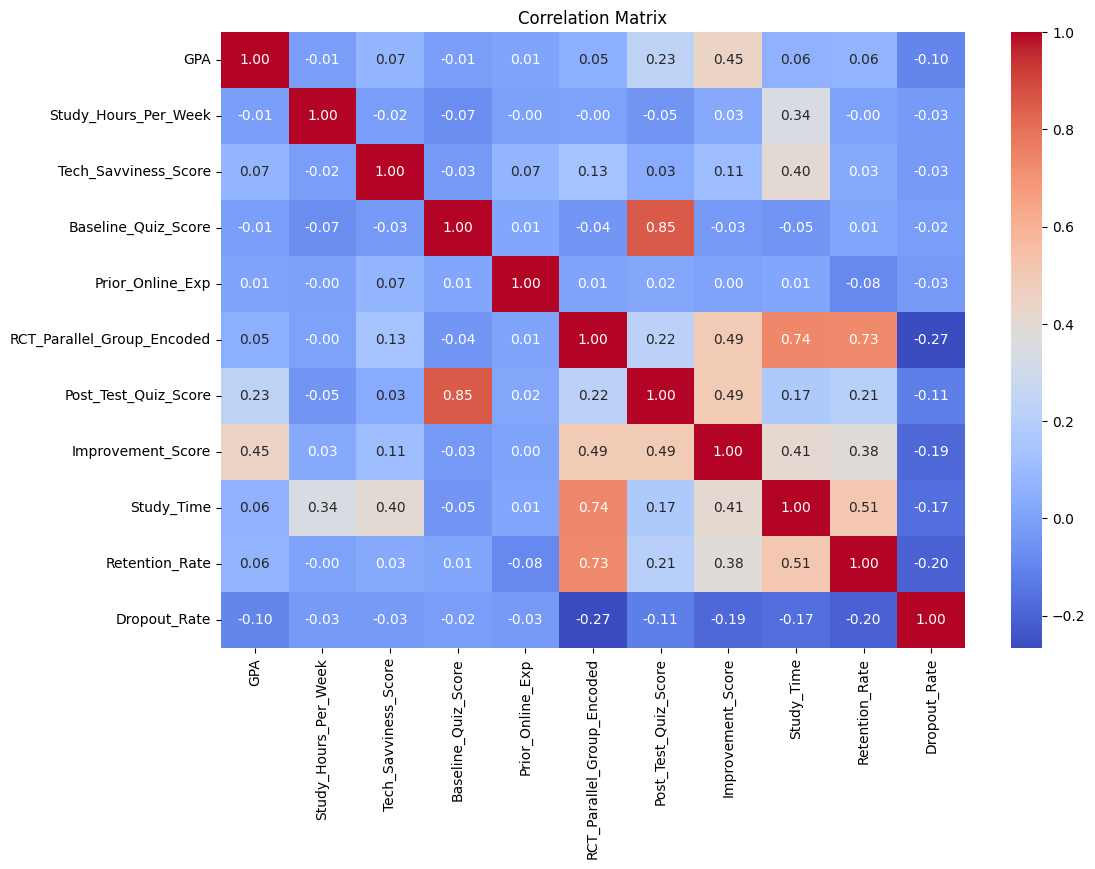

In [19]:
# Encode RCT_Parallel_Group numerically (e.g., Adaptive = 1, Static = 0)
CIM_data["RCT_Parallel_Group_Encoded"] = CIM_data["RCT_Parallel_Group"].map({"Adaptive": 1, "Static": 0})

# Correlation matrix
corr_matrix = CIM_data[["GPA", "Study_Hours_Per_Week", "Tech_Savviness_Score", "Baseline_Quiz_Score", "Prior_Online_Exp",
                        "RCT_Parallel_Group_Encoded", "Post_Test_Quiz_Score", "Improvement_Score", "Study_Time", "Retention_Rate", "Dropout_Rate"]].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### **3.2 Use Dowhy Library to draw DAG diagram**

In [20]:
!apt install libgraphviz-dev
!pip install pygraphviz
!pip install dowhy

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libgail-common libgail18 libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libgail-common libgail18 libgraphviz-dev libgtk2.0-0 libgtk2.0-bin libgtk2.0-common
  libgvc6-plugins-gtk librsvg2-common libxdot4
0 upgraded, 9 newly installed, 0 to remove and 29 not upgraded.
Need to get 2,434 kB of archives.
After this operation, 7,681 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgtk2.0-common all 2.24.33-2ubuntu2.1 [125 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgtk2.0-0 amd64 2.24.33-2ubuntu2.1 [2,038 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgail18 amd64 2.24.33-2ubuntu2.1 [15.9 kB]
Get:4 http://archive.ubun

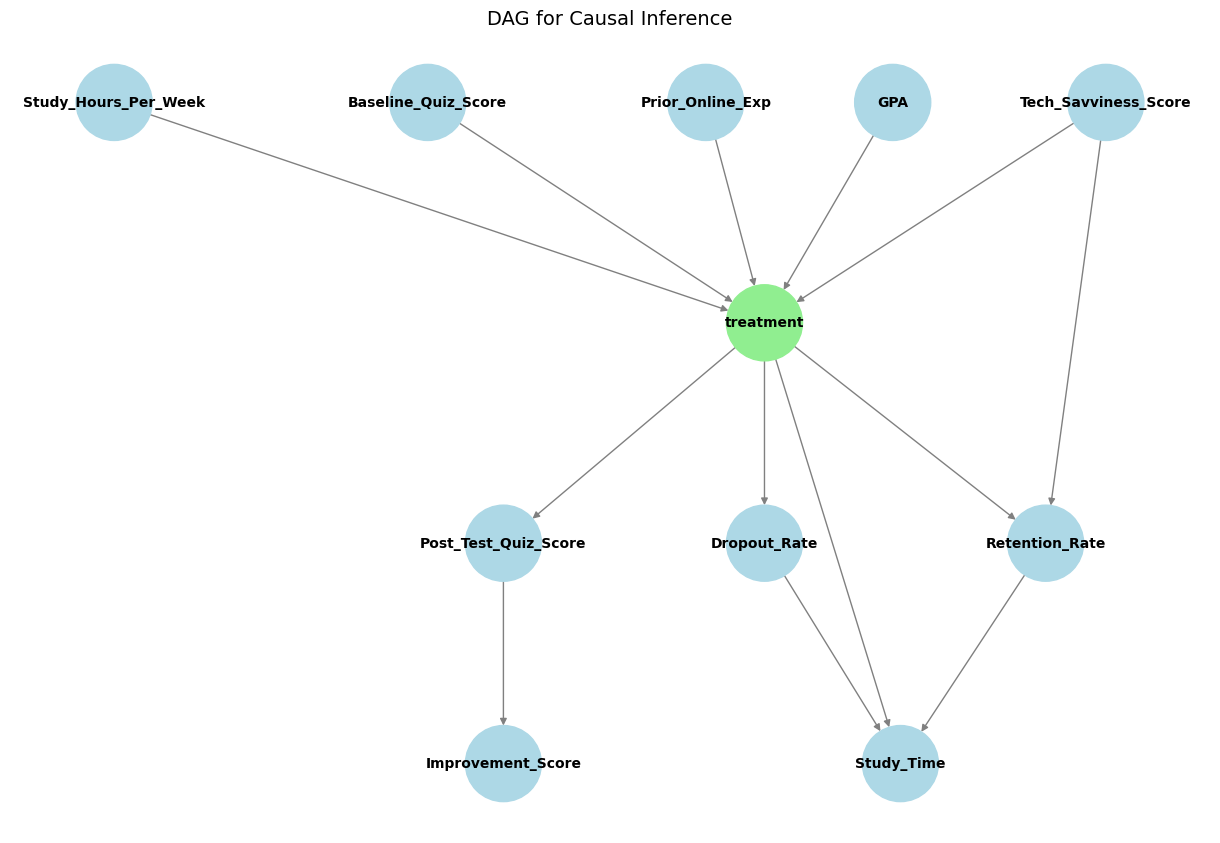

In [21]:
from dowhy import CausalModel
import networkx as nx

# Define the causal relationships
causal_graph = """
digraph {
    GPA -> treatment;
    Study_Hours_Per_Week -> treatment;
    Tech_Savviness_Score -> treatment;
    Baseline_Quiz_Score -> treatment;
    Prior_Online_Exp -> treatment;

    treatment -> Study_Time;
    treatment -> Retention_Rate;
    treatment -> Post_Test_Quiz_Score;
    treatment -> Dropout_Rate;

    Post_Test_Quiz_Score -> Improvement_Score;
    Dropout_Rate -> Study_Time;
    Retention_Rate -> Study_Time;
    Tech_Savviness_Score -> Retention_Rate;
}
"""

# Create a CausalModel
model = CausalModel(
    data=CIM_data,
    treatment="treatment",
    outcome="Improvement_Score",
    graph=causal_graph,
)

# Extract the graph from the CausalModel
G = model._graph._graph

# Use graphviz_layout for a hierarchical (vertical) layout
pos = nx.drawing.nx_agraph.graphviz_layout(G, prog="dot")

# Customize node colors
node_colors = ["lightblue" if node != "treatment" else "lightgreen" for node in G.nodes]

# Draw the graph
plt.figure(figsize=(12, 8))  # Adjust figure size for better visibility
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=3000,
    font_size=10,
    font_weight="bold",
    edge_color="gray",
    arrows=True,
)

# Display the DAG
plt.title("DAG for Causal Inference", fontsize=14)
plt.show()

### **3.3: Estimand, Estimator, Estimate**

In [22]:
# OLS Regression for ATE
print("="*50)
print("OLS Regression for ATE")
print("="*50)

# Encode treatment variable
CIM_data['treatment'] = CIM_data['RCT_Parallel_Group'].apply(lambda x: 1 if x == 'Adaptive' else 0)

# Define covariates
covariates = ['GPA', 'Study_Hours_Per_Week', 'Tech_Savviness_Score',
              'Baseline_Quiz_Score', 'Prior_Online_Exp', 'Age']

# Fit OLS models for each outcome
outcomes = ['Post_Test_Quiz_Score', 'Improvement_Score', 'Study_Time',
            'Retention_Rate', 'Dropout_Rate']

for outcome in outcomes:
    formula = f"{outcome} ~ treatment + " + " + ".join(covariates)
    model = smf.ols(formula, data=CIM_data).fit()
    print(f"\n{outcome} Model Results:")
    print(model.summary())
    ate = model.params['treatment']
    print(f"ATE (treatment effect): {ate:.3f}")
    if model.pvalues['treatment'] < 0.05:
        print("Treatment effect is statistically significant (p < 0.05)")
    else:
        print("Treatment effect is NOT statistically significant")

OLS Regression for ATE

Post_Test_Quiz_Score Model Results:
                             OLS Regression Results                             
Dep. Variable:     Post_Test_Quiz_Score   R-squared:                       0.893
Model:                              OLS   Adj. R-squared:                  0.892
Method:                   Least Squares   F-statistic:                     469.5
Date:                  Sat, 29 Mar 2025   Prob (F-statistic):          3.24e-186
Time:                          01:10:06   Log-Likelihood:                -1091.5
No. Observations:                   400   AIC:                             2199.
Df Residuals:                       392   BIC:                             2231.
Df Model:                             7                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

### **Sensitivity Analysis**

In [23]:
# Sensitivity Analysis
print("\n" + "="*50)
print("Sensitivity Analysis")
print("="*50)

# Rosenbaum Bounds Sensitivity
def rosenbaum_bound(ate, gamma_range=[1.0, 1.5, 2.0]):
    print("\nRosenbaum Bounds Sensitivity Analysis:")
    for gamma in gamma_range:
        bound = ate * gamma
        print(f"For Γ = {gamma}: ATE could range up to {bound:.3f}")
        if bound < 0 and ate > 0 or bound > 0 and ate < 0:
            print("  → Effect could change direction with this level of hidden bias")

# Example for Improvement_Score
improvement_ate = smf.ols("Improvement_Score ~ treatment + " + " + ".join(covariates),
                          data=CIM_data).fit().params['treatment']
rosenbaum_bound(improvement_ate)

# E-value Calculation
def e_value(estimate, sd=1):
    """Calculate E-value for sensitivity to unmeasured confounding"""
    return np.exp(0.5 * (estimate/sd)**2)

print("\nE-value Analysis:")
for outcome in outcomes[:3]:  # Just for first 3 outcomes for example
    model = smf.ols(f"{outcome} ~ treatment", data=CIM_data).fit()
    ate = model.params['treatment']
    e_val = e_value(ate, np.std(CIM_data[outcome]))
    print(f"{outcome}: ATE = {ate:.3f}, E-value = {e_val:.3f}")


Sensitivity Analysis

Rosenbaum Bounds Sensitivity Analysis:
For Γ = 1.0: ATE could range up to 5.245
For Γ = 1.5: ATE could range up to 7.867
For Γ = 2.0: ATE could range up to 10.489

E-value Analysis:
Post_Test_Quiz_Score: ATE = 5.026, E-value = 1.103
Improvement_Score: ATE = 5.880, E-value = 1.632
Study_Time: ATE = 104.741, E-value = 2.952


### **Propensity Score**

In [24]:
# Alternative Framework - Propensity Score Weighting
print("\n" + "="*50)
print("Step 4: Propensity Score Weighting")
print("="*50)

# Estimate propensity scores
from sklearn.linear_model import LogisticRegression

X = CIM_data[covariates]
y = CIM_data['treatment']

propensity_model = LogisticRegression().fit(X, y)
CIM_data['propensity_score'] = propensity_model.predict_proba(X)[:, 1]

# IPW (Inverse Probability Weighting)
CIM_data['weight'] = np.where(CIM_data['treatment'] == 1,
                       1/CIM_data['propensity_score'],
                       1/(1 - CIM_data['propensity_score']))

# Weighted regression
print("\nIPW Regression Results:")
for outcome in outcomes:
    X = sm.add_constant(CIM_data[['treatment'] + covariates])
    wls_model = sm.WLS(CIM_data[outcome], X, weights=CIM_data['weight']).fit()
    print(f"\n{outcome} Model Results:")
    print(f"ATE (treatment effect): {wls_model.params['treatment']:.3f}")
    print(f"p-value: {wls_model.pvalues['treatment']:.4f}")



Step 4: Propensity Score Weighting

IPW Regression Results:

Post_Test_Quiz_Score Model Results:
ATE (treatment effect): 5.232
p-value: 0.0000

Improvement_Score Model Results:
ATE (treatment effect): 5.243
p-value: 0.0000

Study_Time Model Results:
ATE (treatment effect): 98.628
p-value: 0.0000

Retention_Rate Model Results:
ATE (treatment effect): 0.109
p-value: 0.0000

Dropout_Rate Model Results:
ATE (treatment effect): -0.196
p-value: 0.0000


### **DID**

In [25]:
# Difference-in-Differences Analysis
print("\n" + "="*50)
print("Difference-in-Differences Analysis")
print("="*50)

# Create a time variable (assuming you have pre/post data)
# Since we don't have actual time series, we'll simulate it for demonstration
np.random.seed(42)
CIM_data['time'] = np.random.choice([0, 1], size=len(CIM_data))  # 0=pre, 1=post
CIM_data['post_quiz'] = CIM_data['Post_Test_Quiz_Score'] + np.random.normal(0, 2, len(CIM_data))

# DiD model
did_formula = "Post_Test_Quiz_Score ~ treatment * time + " + " + ".join(covariates)
did_model = smf.ols(did_formula, data=CIM_data).fit()
print(did_model.summary())
print("\nDiD Estimate (treatment:time interaction):",
      did_model.params['treatment:time'])


Difference-in-Differences Analysis
                             OLS Regression Results                             
Dep. Variable:     Post_Test_Quiz_Score   R-squared:                       0.894
Model:                              OLS   Adj. R-squared:                  0.891
Method:                   Least Squares   F-statistic:                     364.6
Date:                  Sat, 29 Mar 2025   Prob (F-statistic):          8.37e-184
Time:                          01:10:06   Log-Likelihood:                -1090.9
No. Observations:                   400   AIC:                             2202.
Df Residuals:                       390   BIC:                             2242.
Df Model:                             9                                         
Covariance Type:              nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------